# Single-cell RNA-seq Analysis: PDA-OVA Dataset

This notebook analyzes single-cell RNA-seq data from GSE217121, focusing on PDA-OVA samples with control and treatment conditions.

## Analysis Overview:
- Processes all PDA-OVA 10X Genomics format files (barcodes.tsv.gz, features.tsv.gz, matrix.mtx.gz)
- Applies quality control filtering (min_counts=1000, min_genes=500)
- Combines all PDA-OVA samples into a single AnnData object
- Extracts sample metadata from filenames
- Performs comprehensive quality control analysis

## Dataset Structure:
- **Control samples**: C1, C2, C3 (3 samples)
- **Treatment samples**: MEKi+CD40_Tx1, MEKi+CD40_Tx2, MEKi+CD40_Tx3, MEKi+CD40_Tx4, MEKi+CD40_Tx5 (5 samples)
- **Total PDA-OVA samples**: 8 samples


In [ ]:
# Import necessary libraries
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
from pathlib import Path
import re
from typing import List, Dict, Tuple, Optional

# TCR toolkit
import scirpy as ir

# Set scanpy settings
sc.settings.verbosity = 3  # verbosity level
sc.settings.set_figure_params(dpi=80, facecolor='white')

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")


Libraries imported successfully!


In [5]:
# Find all PDA-OVA 10X Genomics files in the current directory
data_dir = Path('.')

# Find all PDA-OVA matrix files (these indicate the samples)
matrix_files = sorted(list(data_dir.glob('*PDA-OVA*_matrix.mtx.gz')))

print(f"Found {len(matrix_files)} PDA-OVA samples:")
for i, file in enumerate(matrix_files, 1):
    print(f"  {i:2d}. {file.name}")

if len(matrix_files) == 0:
    print("No PDA-OVA matrix files found in the current directory!")
    raise FileNotFoundError("No PDA-OVA matrix files found")

# Verify that we have the corresponding barcodes and features files for each sample
print("\nVerifying file completeness for each sample:")
complete_samples = []
for matrix_file in matrix_files:
    sample_id = matrix_file.name.replace('_matrix.mtx.gz', '')
    barcodes_file = data_dir / f"{sample_id}_barcodes.tsv.gz"
    features_file = data_dir / f"{sample_id}_features.tsv.gz"
    
    if barcodes_file.exists() and features_file.exists():
        complete_samples.append(sample_id)
        print(f"  ✓ {sample_id}: All files present")
    else:
        print(f"  ✗ {sample_id}: Missing files")
        if not barcodes_file.exists():
            print(f"    Missing: {barcodes_file.name}")
        if not features_file.exists():
            print(f"    Missing: {features_file.name}")

print(f"\nComplete samples ready for processing: {len(complete_samples)}")


Found 8 PDA-OVA samples:
   1. GSM6705374_PDA-OVA_C1_matrix.mtx.gz
   2. GSM6705375_PDA-OVA_C2_matrix.mtx.gz
   3. GSM6705376_PDA-OVA_C3_matrix.mtx.gz
   4. GSM6705377_PDA-OVA_MEKi+CD40_Tx1_matrix.mtx.gz
   5. GSM6705378_PDA-OVA_MEKi+CD40_Tx2_matrix.mtx.gz
   6. GSM6705379_PDA-OVA_MEKi+CD40_Tx3_matrix.mtx.gz
   7. GSM6705380_PDA-OVA_MEKi+CD40_Tx4_matrix.mtx.gz
   8. GSM6705381_PDA-OVA_MEKi+CD40_Tx5_matrix.mtx.gz

Verifying file completeness for each sample:
  ✓ GSM6705374_PDA-OVA_C1: All files present
  ✓ GSM6705375_PDA-OVA_C2: All files present
  ✓ GSM6705376_PDA-OVA_C3: All files present
  ✓ GSM6705377_PDA-OVA_MEKi+CD40_Tx1: All files present
  ✓ GSM6705378_PDA-OVA_MEKi+CD40_Tx2: All files present
  ✓ GSM6705379_PDA-OVA_MEKi+CD40_Tx3: All files present
  ✓ GSM6705380_PDA-OVA_MEKi+CD40_Tx4: All files present
  ✓ GSM6705381_PDA-OVA_MEKi+CD40_Tx5: All files present

Complete samples ready for processing: 8


In [6]:
# Function to extract metadata from PDA-OVA filename
def extract_metadata(filename: str) -> Dict[str, str]:
    """Extract sample metadata from PDA-OVA filename"""
    # Pattern: GSM6705XXX_PDA-OVA_[condition]_[replicate]
    # Examples: 
    # - GSM6705374_PDA-OVA_C1
    # - GSM6705377_PDA-OVA_MEKi+CD40_Tx1
    
    pattern = r'GSM(\d+)_PDA-OVA_([^_]+(?:_[^_]+)*)'
    match = re.match(pattern, filename)
    
    if match:
        gsm_id, condition = match.groups()
        
        # Determine if it's control or treatment
        if condition.startswith('C'):
            condition_type = 'Control'
            replicate = condition
        elif 'MEKi+CD40' in condition:
            condition_type = 'Treatment'
            replicate = condition
        else:
            condition_type = 'Unknown'
            replicate = condition
            
        return {
            'gsm_id': f'GSM{gsm_id}',
            'condition': condition,
            'condition_type': condition_type,
            'replicate': replicate,
            'sample_id': f'GSM{gsm_id}_PDA-OVA_{condition}'
        }
    else:
        # Fallback for non-standard filenames
        base_name = filename.replace('_matrix.mtx.gz', '').replace('_barcodes.tsv.gz', '').replace('_features.tsv.gz', '')
        return {
            'gsm_id': 'Unknown',
            'condition': 'Unknown',
            'condition_type': 'Unknown',
            'replicate': 'Unknown',
            'sample_id': base_name
        }

# Test metadata extraction
print("Testing metadata extraction:")
for sample_id in complete_samples[:3]:  # Show first 3 samples
    metadata = extract_metadata(sample_id)
    print(f"  {sample_id} -> {metadata}")


Testing metadata extraction:
  GSM6705374_PDA-OVA_C1 -> {'gsm_id': 'GSM6705374', 'condition': 'C1', 'condition_type': 'Control', 'replicate': 'C1', 'sample_id': 'GSM6705374_PDA-OVA_C1'}
  GSM6705375_PDA-OVA_C2 -> {'gsm_id': 'GSM6705375', 'condition': 'C2', 'condition_type': 'Control', 'replicate': 'C2', 'sample_id': 'GSM6705375_PDA-OVA_C2'}
  GSM6705376_PDA-OVA_C3 -> {'gsm_id': 'GSM6705376', 'condition': 'C3', 'condition_type': 'Control', 'replicate': 'C3', 'sample_id': 'GSM6705376_PDA-OVA_C3'}


In [7]:
# Function to load 10X Genomics format files
def load_10x_sample(sample_id: str, data_dir: Path) -> ad.AnnData:
    """Load a single 10X Genomics sample from barcodes, features, and matrix files"""
    
    # Define file paths
    barcodes_file = data_dir / f"{sample_id}_barcodes.tsv.gz"
    features_file = data_dir / f"{sample_id}_features.tsv.gz"
    matrix_file = data_dir / f"{sample_id}_matrix.mtx.gz"
    
    # Check if all files exist
    for file_path in [barcodes_file, features_file, matrix_file]:
        if not file_path.exists():
            raise FileNotFoundError(f"Required file not found: {file_path}")
    
    # Load the data using scanpy
    adata = sc.read_10x_mtx(
        data_dir,  # directory containing the files
        var_names='gene_symbols',  # use gene symbols for the variable names
        cache=True,  # write a cache file for faster subsequent reading
        prefix=sample_id + '_'  # prefix to add to barcode names
    )
    
    # Make variable names unique
    adata.var_names_make_unique()
    
    # Transpose to get cells as rows and genes as columns
    adata = adata.T
    
    return adata

# Test loading one sample
print("Testing 10X file loading:")
test_sample = complete_samples[0]
print(f"Loading sample: {test_sample}")
try:
    test_adata = load_10x_sample(test_sample, data_dir)
    print(f"  ✓ Successfully loaded {test_sample}")
    print(f"  Shape: {test_adata.shape}")
    print(f"  Variables: {list(test_adata.var.columns)}")
    print(f"  Observations: {list(test_adata.obs.columns)}")
except Exception as e:
    print(f"  ✗ Error loading {test_sample}: {str(e)}")


Testing 10X file loading:
Loading sample: GSM6705374_PDA-OVA_C1
... reading from cache file cache\GSM6705374_PDA-OVA_C1_matrix.h5ad
  ✓ Successfully loaded GSM6705374_PDA-OVA_C1
  Shape: (31053, 5055)
  Variables: []
  Observations: ['gene_ids', 'feature_types']


In [8]:
# Function to load TCR data (clonotypes and filtered contig annotations)
def load_tcr_data(sample_id: str, data_dir: Path) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """Load TCR clonotypes and filtered contig annotations for a sample"""
    
    # Define file paths
    clonotypes_file = data_dir / f"{sample_id}_clonotypes.csv.gz"
    contig_file = data_dir / f"{sample_id}_filtered_contig_annotations.csv.gz"
    
    # Check if files exist
    if not clonotypes_file.exists():
        print(f"  Warning: Clonotypes file not found: {clonotypes_file}")
        return None, None
    if not contig_file.exists():
        print(f"  Warning: Contig file not found: {contig_file}")
        return None, None
    
    # Load clonotypes data
    clonotypes_df = pd.read_csv(clonotypes_file, compression='gzip')
    
    # Load filtered contig annotations
    contig_df = pd.read_csv(contig_file, compression='gzip')
    
    # Add sample information
    clonotypes_df['sample_id'] = sample_id
    contig_df['sample_id'] = sample_id
    
    return clonotypes_df, contig_df

# Function to process TCR data and create TCR metadata for each cell
def process_tcr_data(contig_df: pd.DataFrame, clonotypes_df: pd.DataFrame) -> pd.DataFrame:
    """Process TCR data to create cell-level TCR metadata"""
    
    if contig_df is None or clonotypes_df is None:
        return None
    
    # Filter for productive, high-confidence contigs
    productive_contigs = contig_df[
        (contig_df['productive'] == True) & 
        (contig_df['high_confidence'] == True) &
        (contig_df['is_cell'] == True)
    ].copy()
    
    # Create cell-level TCR summary
    tcr_cells = []
    
    for barcode in productive_contigs['barcode'].unique():
        cell_contigs = productive_contigs[productive_contigs['barcode'] == barcode]
        
        # Get alpha and beta chains
        alpha_contigs = cell_contigs[cell_contigs['chain'] == 'TRA']
        beta_contigs = cell_contigs[cell_contigs['chain'] == 'TRB']
        
        # Create cell record
        cell_record = {
            'barcode': barcode,
            'sample_id': cell_contigs['sample_id'].iloc[0],
            'has_alpha': len(alpha_contigs) > 0,
            'has_beta': len(beta_contigs) > 0,
            'has_paired_tcr': len(alpha_contigs) > 0 and len(beta_contigs) > 0,
            'n_alpha_chains': len(alpha_contigs),
            'n_beta_chains': len(beta_contigs),
            'total_tcr_chains': len(cell_contigs)
        }
        
        # Add alpha chain information (take the first one if multiple)
        if len(alpha_contigs) > 0:
            alpha = alpha_contigs.iloc[0]
            cell_record.update({
                'alpha_v_gene': alpha['v_gene'],
                'alpha_j_gene': alpha['j_gene'],
                'alpha_c_gene': alpha['c_gene'],
                'alpha_cdr3': alpha['cdr3'],
                'alpha_cdr3_nt': alpha['cdr3_nt'],
                'alpha_raw_clonotype_id': alpha['raw_clonotype_id']
            })
        else:
            cell_record.update({
                'alpha_v_gene': None,
                'alpha_j_gene': None,
                'alpha_c_gene': None,
                'alpha_cdr3': None,
                'alpha_cdr3_nt': None,
                'alpha_raw_clonotype_id': None
            })
        
        # Add beta chain information (take the first one if multiple)
        if len(beta_contigs) > 0:
            beta = beta_contigs.iloc[0]
            cell_record.update({
                'beta_v_gene': beta['v_gene'],
                'beta_d_gene': beta['d_gene'],
                'beta_j_gene': beta['j_gene'],
                'beta_c_gene': beta['c_gene'],
                'beta_cdr3': beta['cdr3'],
                'beta_cdr3_nt': beta['cdr3_nt'],
                'beta_raw_clonotype_id': beta['raw_clonotype_id']
            })
        else:
            cell_record.update({
                'beta_v_gene': None,
                'beta_d_gene': None,
                'beta_j_gene': None,
                'beta_c_gene': None,
                'beta_cdr3': None,
                'beta_cdr3_nt': None,
                'beta_raw_clonotype_id': None
            })
        
        # Add clonotype information if available
        if cell_record['alpha_raw_clonotype_id'] and cell_record['alpha_raw_clonotype_id'] in clonotypes_df['clonotype_id'].values:
            clonotype_info = clonotypes_df[clonotypes_df['clonotype_id'] == cell_record['alpha_raw_clonotype_id']].iloc[0]
            cell_record.update({
                'clonotype_id': clonotype_info['clonotype_id'],
                'clonotype_frequency': clonotype_info['frequency'],
                'clonotype_proportion': clonotype_info['proportion'],
                'clonotype_cdr3s_aa': clonotype_info['cdr3s_aa'],
                'clonotype_cdr3s_nt': clonotype_info['cdr3s_nt']
            })
        else:
            cell_record.update({
                'clonotype_id': None,
                'clonotype_frequency': None,
                'clonotype_proportion': None,
                'clonotype_cdr3s_aa': None,
                'clonotype_cdr3s_nt': None
            })
        
        tcr_cells.append(cell_record)
    
    return pd.DataFrame(tcr_cells)

# Test TCR loading
print("Testing TCR data loading:")
test_sample = complete_samples[0]
print(f"Loading TCR data for sample: {test_sample}")
try:
    clonotypes_df, contig_df = load_tcr_data(test_sample, data_dir)
    if clonotypes_df is not None and contig_df is not None:
        print(f"  ✓ Successfully loaded TCR data for {test_sample}")
        print(f"  Clonotypes shape: {clonotypes_df.shape}")
        print(f"  Contigs shape: {contig_df.shape}")
        
        # Process TCR data
        tcr_cells_df = process_tcr_data(contig_df, clonotypes_df)
        if tcr_cells_df is not None:
            print(f"  Processed TCR cells: {tcr_cells_df.shape}")
            print(f"  Cells with paired TCR: {tcr_cells_df['has_paired_tcr'].sum()}")
            print(f"  TCR columns: {list(tcr_cells_df.columns)}")
    else:
        print(f"  ✗ No TCR data found for {test_sample}")
except Exception as e:
    print(f"  ✗ Error loading TCR data for {test_sample}: {str(e)}")


Testing TCR data loading:
Loading TCR data for sample: GSM6705374_PDA-OVA_C1
  ✗ No TCR data found for GSM6705374_PDA-OVA_C1


In [ ]:
# TCR loading via scirpy using filtered contigs, keep top-read TRA/TRB per cell
from pathlib import Path

def _find_vdj_files_by_suffix(sample_id: str, data_dir: Path):
    # exact
    clonotypes = data_dir / f"{sample_id}_clonotypes.csv.gz"
    contigs = data_dir / f"{sample_id}_filtered_contig_annotations.csv.gz"
    if clonotypes.exists() and contigs.exists():
        return clonotypes, contigs
    # fallback by suffix
    suffix = sample_id.split('_', 1)[1] if '_' in sample_id else sample_id
    clonos = sorted(data_dir.glob(f"*{suffix}_clonotypes.csv.gz"))
    conts = sorted(data_dir.glob(f"*{suffix}_filtered_contig_annotations.csv.gz"))
    if clonos and conts:
        return clonos[0], conts[0]
    return None, None


def load_tcr_with_scirpy(sample_id: str, data_dir: Path) -> Optional[pd.DataFrame]:
    clonotypes_file, contig_file = _find_vdj_files_by_suffix(sample_id, data_dir)
    if clonotypes_file is None or contig_file is None:
        print(f"  Warning: No VDJ files found for {sample_id}")
        return None
    try:
        vdj = ir.io.read_10x_vdj(
            path=str(contig_file),
            clonotype_file=str(clonotypes_file),
            filtered_contig=True
        )
    except Exception as e:
        print(f"  ✗ scirpy read_10x_vdj failed for {sample_id}: {e}")
        return None

    # vdj is an AnnData with IR tables in vdj.obs / vdj.obsm
    # Extract contigs table
    contigs = ir.tl.chain_qc(vdj, inplace=False)
    # scirpy stores per-chain information in vdj.obs/obsm; easier: use ir.get.airr to get long table
    airr = ir.get.airr(vdj)
    if airr is None or len(airr) == 0:
        print(f"  Warning: Empty AIRR table for {sample_id}")
        return None

    # Keep productive, cell-associated contigs
    # Columns per 10x: productive, is_cell, chain, cdr3, cdr3_nt, v_call (v_gene), j_call, d_call, c_call, read_count
    airr = airr.copy()
    for col in ["productive", "is_cell"]:
        if col in airr.columns:
            airr[col] = airr[col].astype(str).str.lower().isin(["true", "t", "1"])
    mask = True
    if "productive" in airr.columns:
        mask &= airr["productive"]
    if "is_cell" in airr.columns:
        mask &= airr["is_cell"]
    airr = airr[mask]

    # Pick one alpha (TRA) and one beta (TRB) per cell by highest read_count (fallback to umi_count)
    if "read_count" not in airr.columns and "umi_count" in airr.columns:
        airr["read_count"] = airr["umi_count"]
    if "read_count" not in airr.columns:
        # fallback: give all read_count=1
        airr["read_count"] = 1

    results = []
    for cell, df in airr.groupby("cell_id"):
        alpha = df[df["chain"].eq("TRA")].sort_values("read_count", ascending=False).head(1)
        beta = df[df["chain"].eq("TRB")].sort_values("read_count", ascending=False).head(1)
        rec = {
            "barcode": cell,
            "sample_id": sample_id,
            "has_alpha": len(alpha) > 0,
            "has_beta": len(beta) > 0,
            "has_paired_tcr": len(alpha) > 0 and len(beta) > 0,
            "n_alpha_chains": int((df["chain"] == "TRA").sum()),
            "n_beta_chains": int((df["chain"] == "TRB").sum()),
            "total_tcr_chains": int(len(df)),
        }
        if len(alpha) > 0:
            a = alpha.iloc[0]
            rec.update({
                "alpha_v_gene": a.get("v_call"),
                "alpha_j_gene": a.get("j_call"),
                "alpha_c_gene": a.get("c_call"),
                "alpha_cdr3": a.get("cdr3"),
                "alpha_cdr3_nt": a.get("cdr3_nt"),
                "alpha_raw_clonotype_id": a.get("raw_clonotype_id") or a.get("clonotype_id")
            })
        else:
            rec.update({k: None for k in [
                "alpha_v_gene","alpha_j_gene","alpha_c_gene","alpha_cdr3","alpha_cdr3_nt","alpha_raw_clonotype_id"
            ]})
        if len(beta) > 0:
            b = beta.iloc[0]
            rec.update({
                "beta_v_gene": b.get("v_call"),
                "beta_d_gene": b.get("d_call"),
                "beta_j_gene": b.get("j_call"),
                "beta_c_gene": b.get("c_call"),
                "beta_cdr3": b.get("cdr3"),
                "beta_cdr3_nt": b.get("cdr3_nt"),
                "beta_raw_clonotype_id": b.get("raw_clonotype_id") or b.get("clonotype_id")
            })
        else:
            rec.update({k: None for k in [
                "beta_v_gene","beta_d_gene","beta_j_gene","beta_c_gene","beta_cdr3","beta_cdr3_nt","beta_raw_clonotype_id"
            ]})
        results.append(rec)

    if not results:
        return None
    return pd.DataFrame(results)


def integrate_tcr_obs(adata: ad.AnnData, tcr_cells_df: pd.DataFrame, sample_id: str) -> None:
    # Prepare mapping from GEX barcodes to TCR barcodes
    gex_barcodes = adata.obs.index.str.replace(f"{sample_id}_", "", regex=False)
    tcr_df = tcr_cells_df.set_index("barcode")

    tcr_columns = [
        'has_alpha', 'has_beta', 'has_paired_tcr', 'n_alpha_chains', 'n_beta_chains', 'total_tcr_chains',
        'alpha_v_gene', 'alpha_j_gene', 'alpha_c_gene', 'alpha_cdr3', 'alpha_cdr3_nt', 'alpha_raw_clonotype_id',
        'beta_v_gene', 'beta_d_gene', 'beta_j_gene', 'beta_c_gene', 'beta_cdr3', 'beta_cdr3_nt', 'beta_raw_clonotype_id'
    ]
    for col in tcr_columns:
        adata.obs[col] = None

    for i, gex_barcode in enumerate(gex_barcodes):
        if gex_barcode in tcr_df.index:
            vals = tcr_df.loc[gex_barcode]
            if isinstance(vals, pd.DataFrame):
                vals = vals.iloc[0]
            for col in tcr_columns:
                adata.obs.iloc[i, adata.obs.columns.get_loc(col)] = vals.get(col)



In [9]:
# Process all PDA-OVA samples using a loop
def process_single_sample(sample_id: str, data_dir: Path) -> ad.AnnData:
    """Process a single PDA-OVA sample with filtering"""
    print(f"Processing {sample_id}...")
    
    # Load data
    adata = load_10x_sample(sample_id, data_dir)
    
    # Extract metadata from sample ID
    metadata = extract_metadata(sample_id)
    
    # Add metadata to observations
    for key, value in metadata.items():
        adata.obs[key] = value
    
    print(f"  Original shape: {adata.shape}")
    
    # Apply filtering
    sc.pp.filter_cells(adata, min_counts=1000)   # drop empty droplets
    sc.pp.filter_cells(adata, min_genes=500)     # filter cells with too few genes
    
    print(f"  After filtering: {adata.shape}")
    
    return adata

# Process all PDA-OVA samples
print("\\n" + "="*60)
print("PROCESSING ALL PDA-OVA SAMPLES")
print("="*60)

processed_samples = []
for sample_id in complete_samples:
    try:
        adata_sample = process_single_sample(sample_id, data_dir)
        processed_samples.append(adata_sample)
        print(f"  ✓ Successfully processed {sample_id}")
    except Exception as e:
        print(f"  ✗ Error processing {sample_id}: {str(e)}")
        continue
    print()

print(f"Successfully processed {len(processed_samples)} out of {len(complete_samples)} PDA-OVA samples")


\n============================================================
PROCESSING ALL PDA-OVA SAMPLES
Processing GSM6705374_PDA-OVA_C1...
... reading from cache file cache\GSM6705374_PDA-OVA_C1_matrix.h5ad
  Original shape: (31053, 5055)
filtered out 25501 cells that have less than 1000 counts
filtered out 52 cells that have less than 500 genes expressed
  After filtering: (5500, 5055)
  ✓ Successfully processed GSM6705374_PDA-OVA_C1

Processing GSM6705375_PDA-OVA_C2...
... reading from cache file cache\GSM6705375_PDA-OVA_C2_matrix.h5ad
  Original shape: (31053, 4332)
filtered out 26199 cells that have less than 1000 counts
filtered out 68 cells that have less than 500 genes expressed
  After filtering: (4786, 4332)
  ✓ Successfully processed GSM6705375_PDA-OVA_C2

Processing GSM6705376_PDA-OVA_C3...
... reading from cache file cache\GSM6705376_PDA-OVA_C3_matrix.h5ad
  Original shape: (31053, 4786)
filtered out 28524 cells that have less than 1000 counts
filtered out 35 cells that have less th

In [10]:
# Combine all processed PDA-OVA samples
if len(processed_samples) == 0:
    raise ValueError("No PDA-OVA samples were successfully processed!")

print("\\n" + "="*60)
print("COMBINING ALL PDA-OVA SAMPLES")
print("="*60)

# Combine datasets
adata_combined = ad.concat(processed_samples, join='outer', index_unique='_')

print(f"Combined data shape: {adata_combined.shape}")
print(f"Total cells: {adata_combined.n_obs}")
print(f"Total genes: {adata_combined.n_vars}")

# Display sample composition
print("\\nSample composition:")
sample_counts = adata_combined.obs['sample_id'].value_counts()
for sample, count in sample_counts.items():
    print(f"  {sample}: {count:,} cells")

print("\\nCondition type distribution:")
condition_type_counts = adata_combined.obs['condition_type'].value_counts()
for condition_type, count in condition_type_counts.items():
    print(f"  {condition_type}: {count:,} cells")

print("\\nCondition distribution:")
condition_counts = adata_combined.obs['condition'].value_counts()
for condition, count in condition_counts.items():
    print(f"  {condition}: {count:,} cells")

print("\\nReplicate distribution:")
replicate_counts = adata_combined.obs['replicate'].value_counts()
for replicate, count in replicate_counts.items():
    print(f"  {replicate}: {count:,} cells")


\n============================================================
COMBINING ALL PDA-OVA SAMPLES
Combined data shape: (32457, 41609)
Total cells: 32457
Total genes: 41609
\nSample composition:
  GSM6705374_PDA-OVA_C1: 5,500 cells
  GSM6705378_PDA-OVA_MEKi+CD40_Tx2: 5,235 cells
  GSM6705375_PDA-OVA_C2: 4,786 cells
  GSM6705379_PDA-OVA_MEKi+CD40_Tx3: 4,775 cells
  GSM6705381_PDA-OVA_MEKi+CD40_Tx5: 3,929 cells
  GSM6705377_PDA-OVA_MEKi+CD40_Tx1: 2,996 cells
  GSM6705380_PDA-OVA_MEKi+CD40_Tx4: 2,742 cells
  GSM6705376_PDA-OVA_C3: 2,494 cells
\nCondition type distribution:
  Treatment: 19,677 cells
  Control: 12,780 cells
\nCondition distribution:
  C1: 5,500 cells
  MEKi+CD40_Tx2: 5,235 cells
  C2: 4,786 cells
  MEKi+CD40_Tx3: 4,775 cells
  MEKi+CD40_Tx5: 3,929 cells
  MEKi+CD40_Tx1: 2,996 cells
  MEKi+CD40_Tx4: 2,742 cells
  C3: 2,494 cells
\nReplicate distribution:
  C1: 5,500 cells
  MEKi+CD40_Tx2: 5,235 cells
  C2: 4,786 cells
  MEKi+CD40_Tx3: 4,775 cells
  MEKi+CD40_Tx5: 3,929 cells
  MEK

In [11]:
# Enhanced processing function with TCR integration
def process_single_sample_with_tcr(sample_id: str, data_dir: Path) -> ad.AnnData:
    """Process a single PDA-OVA sample with filtering and TCR integration"""
    print(f"Processing {sample_id}...")
    
    # Load GEX data
    adata = load_10x_sample(sample_id, data_dir)
    
    # Extract metadata from sample ID
    metadata = extract_metadata(sample_id)
    
    # Add metadata to observations
    for key, value in metadata.items():
        adata.obs[key] = value
    
    print(f"  Original GEX shape: {adata.shape}")
    
    # Load and process TCR data
    clonotypes_df, contig_df = load_tcr_data(sample_id, data_dir)
    tcr_cells_df = None
    
    if clonotypes_df is not None and contig_df is not None:
        tcr_cells_df = process_tcr_data(contig_df, clonotypes_df)
        if tcr_cells_df is not None:
            print(f"  TCR data: {tcr_cells_df.shape[0]} cells with TCR information")
            print(f"  Cells with paired TCR: {tcr_cells_df['has_paired_tcr'].sum()}")
        else:
            print(f"  Warning: Could not process TCR data for {sample_id}")
    else:
        print(f"  Warning: No TCR data found for {sample_id}")
    
    # Apply GEX filtering
    sc.pp.filter_cells(adata, min_counts=1000)   # drop empty droplets
    sc.pp.filter_cells(adata, min_genes=500)     # filter cells with too few genes
    
    print(f"  After GEX filtering: {adata.shape}")
    
    # Integrate TCR data with GEX data
    if tcr_cells_df is not None:
        # Create barcode mapping (remove sample prefix from GEX barcodes)
        gex_barcodes = adata.obs.index.str.replace(f"{sample_id}_", "", regex=False)
        
        # Initialize TCR columns in adata.obs
        tcr_columns = [
            'has_alpha', 'has_beta', 'has_paired_tcr', 'n_alpha_chains', 'n_beta_chains', 'total_tcr_chains',
            'alpha_v_gene', 'alpha_j_gene', 'alpha_c_gene', 'alpha_cdr3', 'alpha_cdr3_nt', 'alpha_raw_clonotype_id',
            'beta_v_gene', 'beta_d_gene', 'beta_j_gene', 'beta_c_gene', 'beta_cdr3', 'beta_cdr3_nt', 'beta_raw_clonotype_id',
            'clonotype_id', 'clonotype_frequency', 'clonotype_proportion', 'clonotype_cdr3s_aa', 'clonotype_cdr3s_nt'
        ]
        
        for col in tcr_columns:
            adata.obs[col] = None
        
        # Map TCR data to GEX cells
        tcr_mapping = tcr_cells_df.set_index('barcode')
        
        for i, gex_barcode in enumerate(gex_barcodes):
            if gex_barcode in tcr_mapping.index:
                tcr_info = tcr_mapping.loc[gex_barcode]
                for col in tcr_columns:
                    adata.obs.iloc[i, adata.obs.columns.get_loc(col)] = tcr_info[col]
        
        # Calculate TCR statistics
        n_cells_with_tcr = adata.obs['has_paired_tcr'].notna().sum()
        # Convert to boolean for counting True values
        tcr_bool = adata.obs['has_paired_tcr'].astype(str).map({'True': True, 'False': False, 'None': False, 'nan': False})
        n_cells_with_paired_tcr = tcr_bool.sum() if tcr_bool.notna().any() else 0
        
        print(f"  TCR integration: {n_cells_with_tcr} cells with TCR data, {n_cells_with_paired_tcr} with paired TCR")
    else:
        # Initialize empty TCR columns
        tcr_columns = [
            'has_alpha', 'has_beta', 'has_paired_tcr', 'n_alpha_chains', 'n_beta_chains', 'total_tcr_chains',
            'alpha_v_gene', 'alpha_j_gene', 'alpha_c_gene', 'alpha_cdr3', 'alpha_cdr3_nt', 'alpha_raw_clonotype_id',
            'beta_v_gene', 'beta_d_gene', 'beta_j_gene', 'beta_c_gene', 'beta_cdr3', 'beta_cdr3_nt', 'beta_raw_clonotype_id',
            'clonotype_id', 'clonotype_frequency', 'clonotype_proportion', 'clonotype_cdr3s_aa', 'clonotype_cdr3s_nt'
        ]
        
        for col in tcr_columns:
            adata.obs[col] = None
        
        print(f"  TCR integration: No TCR data available")
    
    return adata

# Test the enhanced processing function
print("Testing enhanced processing with TCR integration:")
test_sample = complete_samples[0]
try:
    test_adata = process_single_sample_with_tcr(test_sample, data_dir)
    print(f"  ✓ Successfully processed {test_sample} with TCR integration")
    print(f"  Final shape: {test_adata.shape}")
    print(f"  TCR columns added: {[col for col in test_adata.obs.columns if col.startswith(('has_', 'alpha_', 'beta_', 'clonotype_', 'n_'))]}")
except Exception as e:
    print(f"  ✗ Error processing {test_sample}: {str(e)}")


Testing enhanced processing with TCR integration:
Processing GSM6705374_PDA-OVA_C1...
... reading from cache file cache\GSM6705374_PDA-OVA_C1_matrix.h5ad
  Original GEX shape: (31053, 5055)
filtered out 25501 cells that have less than 1000 counts
filtered out 52 cells that have less than 500 genes expressed
  After GEX filtering: (5500, 5055)
  TCR integration: No TCR data available
  ✓ Successfully processed GSM6705374_PDA-OVA_C1 with TCR integration
  Final shape: (5500, 5055)
  TCR columns added: ['n_counts', 'n_genes', 'has_alpha', 'has_beta', 'has_paired_tcr', 'n_alpha_chains', 'n_beta_chains', 'alpha_v_gene', 'alpha_j_gene', 'alpha_c_gene', 'alpha_cdr3', 'alpha_cdr3_nt', 'alpha_raw_clonotype_id', 'beta_v_gene', 'beta_d_gene', 'beta_j_gene', 'beta_c_gene', 'beta_cdr3', 'beta_cdr3_nt', 'beta_raw_clonotype_id', 'clonotype_id', 'clonotype_frequency', 'clonotype_proportion', 'clonotype_cdr3s_aa', 'clonotype_cdr3s_nt']


In [12]:
# Calculate comprehensive QC metrics
print("\\n" + "="*60)
print("CALCULATING QC METRICS")
print("="*60)

# Make variable names unique
adata_combined.var_names_make_unique()

# Identify mitochondrial and ribosomal genes (mouse)
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('mt-')  # mouse mitochondrial genes
adata_combined.var['ribo'] = adata_combined.var_names.str.startswith(('Rps', 'Rpl'))  # mouse ribosomal genes

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_combined, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['ribo'], percent_top=None, log1p=False, inplace=True)

print("QC metrics calculated successfully!")

# Display basic statistics
print("\\nQuality Control Statistics:")
print(f"\\nTotal UMI counts per cell:")
print(adata_combined.obs['total_counts'].describe())

print(f"\\nNumber of genes per cell:")
print(adata_combined.obs['n_genes_by_counts'].describe())

print(f"\\nMitochondrial gene percentage:")
print(adata_combined.obs['pct_counts_mt'].describe())

print(f"\\nRibosomal gene percentage:")
print(adata_combined.obs['pct_counts_ribo'].describe())


\n============================================================
CALCULATING QC METRICS


QC metrics calculated successfully!
\nQuality Control Statistics:
\nTotal UMI counts per cell:
count     32457.000000
mean       7001.586914
std       23720.460938
min        1000.000000
25%        1455.000000
50%        2246.000000
75%        4377.000000
max      806603.000000
Name: total_counts, dtype: float64
\nNumber of genes per cell:
count    32457.000000
mean      1783.034107
std       1044.237774
min        501.000000
25%       1058.000000
50%       1446.000000
75%       2174.000000
max       8439.000000
Name: n_genes_by_counts, dtype: float64
\nMitochondrial gene percentage:
count    32457.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: pct_counts_mt, dtype: float64
\nRibosomal gene percentage:
count    32457.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: pct_counts_ribo, dtype: float64


In [13]:
# Process all PDA-OVA samples with TCR integration (alternative approach)
print("\\n" + "="*60)
print("PROCESSING ALL PDA-OVA SAMPLES WITH TCR INTEGRATION")
print("="*60)

processed_samples_with_tcr = []
for sample_id in complete_samples:
    try:
        adata_sample = process_single_sample_with_tcr(sample_id, data_dir)
        processed_samples_with_tcr.append(adata_sample)
        print(f"  ✓ Successfully processed {sample_id} with TCR integration")
    except Exception as e:
        print(f"  ✗ Error processing {sample_id}: {str(e)}")
        continue
    print()

print(f"Successfully processed {len(processed_samples_with_tcr)} out of {len(complete_samples)} PDA-OVA samples with TCR integration")


\n============================================================
PROCESSING ALL PDA-OVA SAMPLES WITH TCR INTEGRATION
Processing GSM6705374_PDA-OVA_C1...
... reading from cache file cache\GSM6705374_PDA-OVA_C1_matrix.h5ad
  Original GEX shape: (31053, 5055)
filtered out 25501 cells that have less than 1000 counts
filtered out 52 cells that have less than 500 genes expressed
  After GEX filtering: (5500, 5055)
  TCR integration: No TCR data available
  ✓ Successfully processed GSM6705374_PDA-OVA_C1 with TCR integration

Processing GSM6705375_PDA-OVA_C2...
... reading from cache file cache\GSM6705375_PDA-OVA_C2_matrix.h5ad
  Original GEX shape: (31053, 4332)
filtered out 26199 cells that have less than 1000 counts
filtered out 68 cells that have less than 500 genes expressed
  After GEX filtering: (4786, 4332)
  TCR integration: No TCR data available
  ✓ Successfully processed GSM6705375_PDA-OVA_C2 with TCR integration

Processing GSM6705376_PDA-OVA_C3...
... reading from cache file cache\G

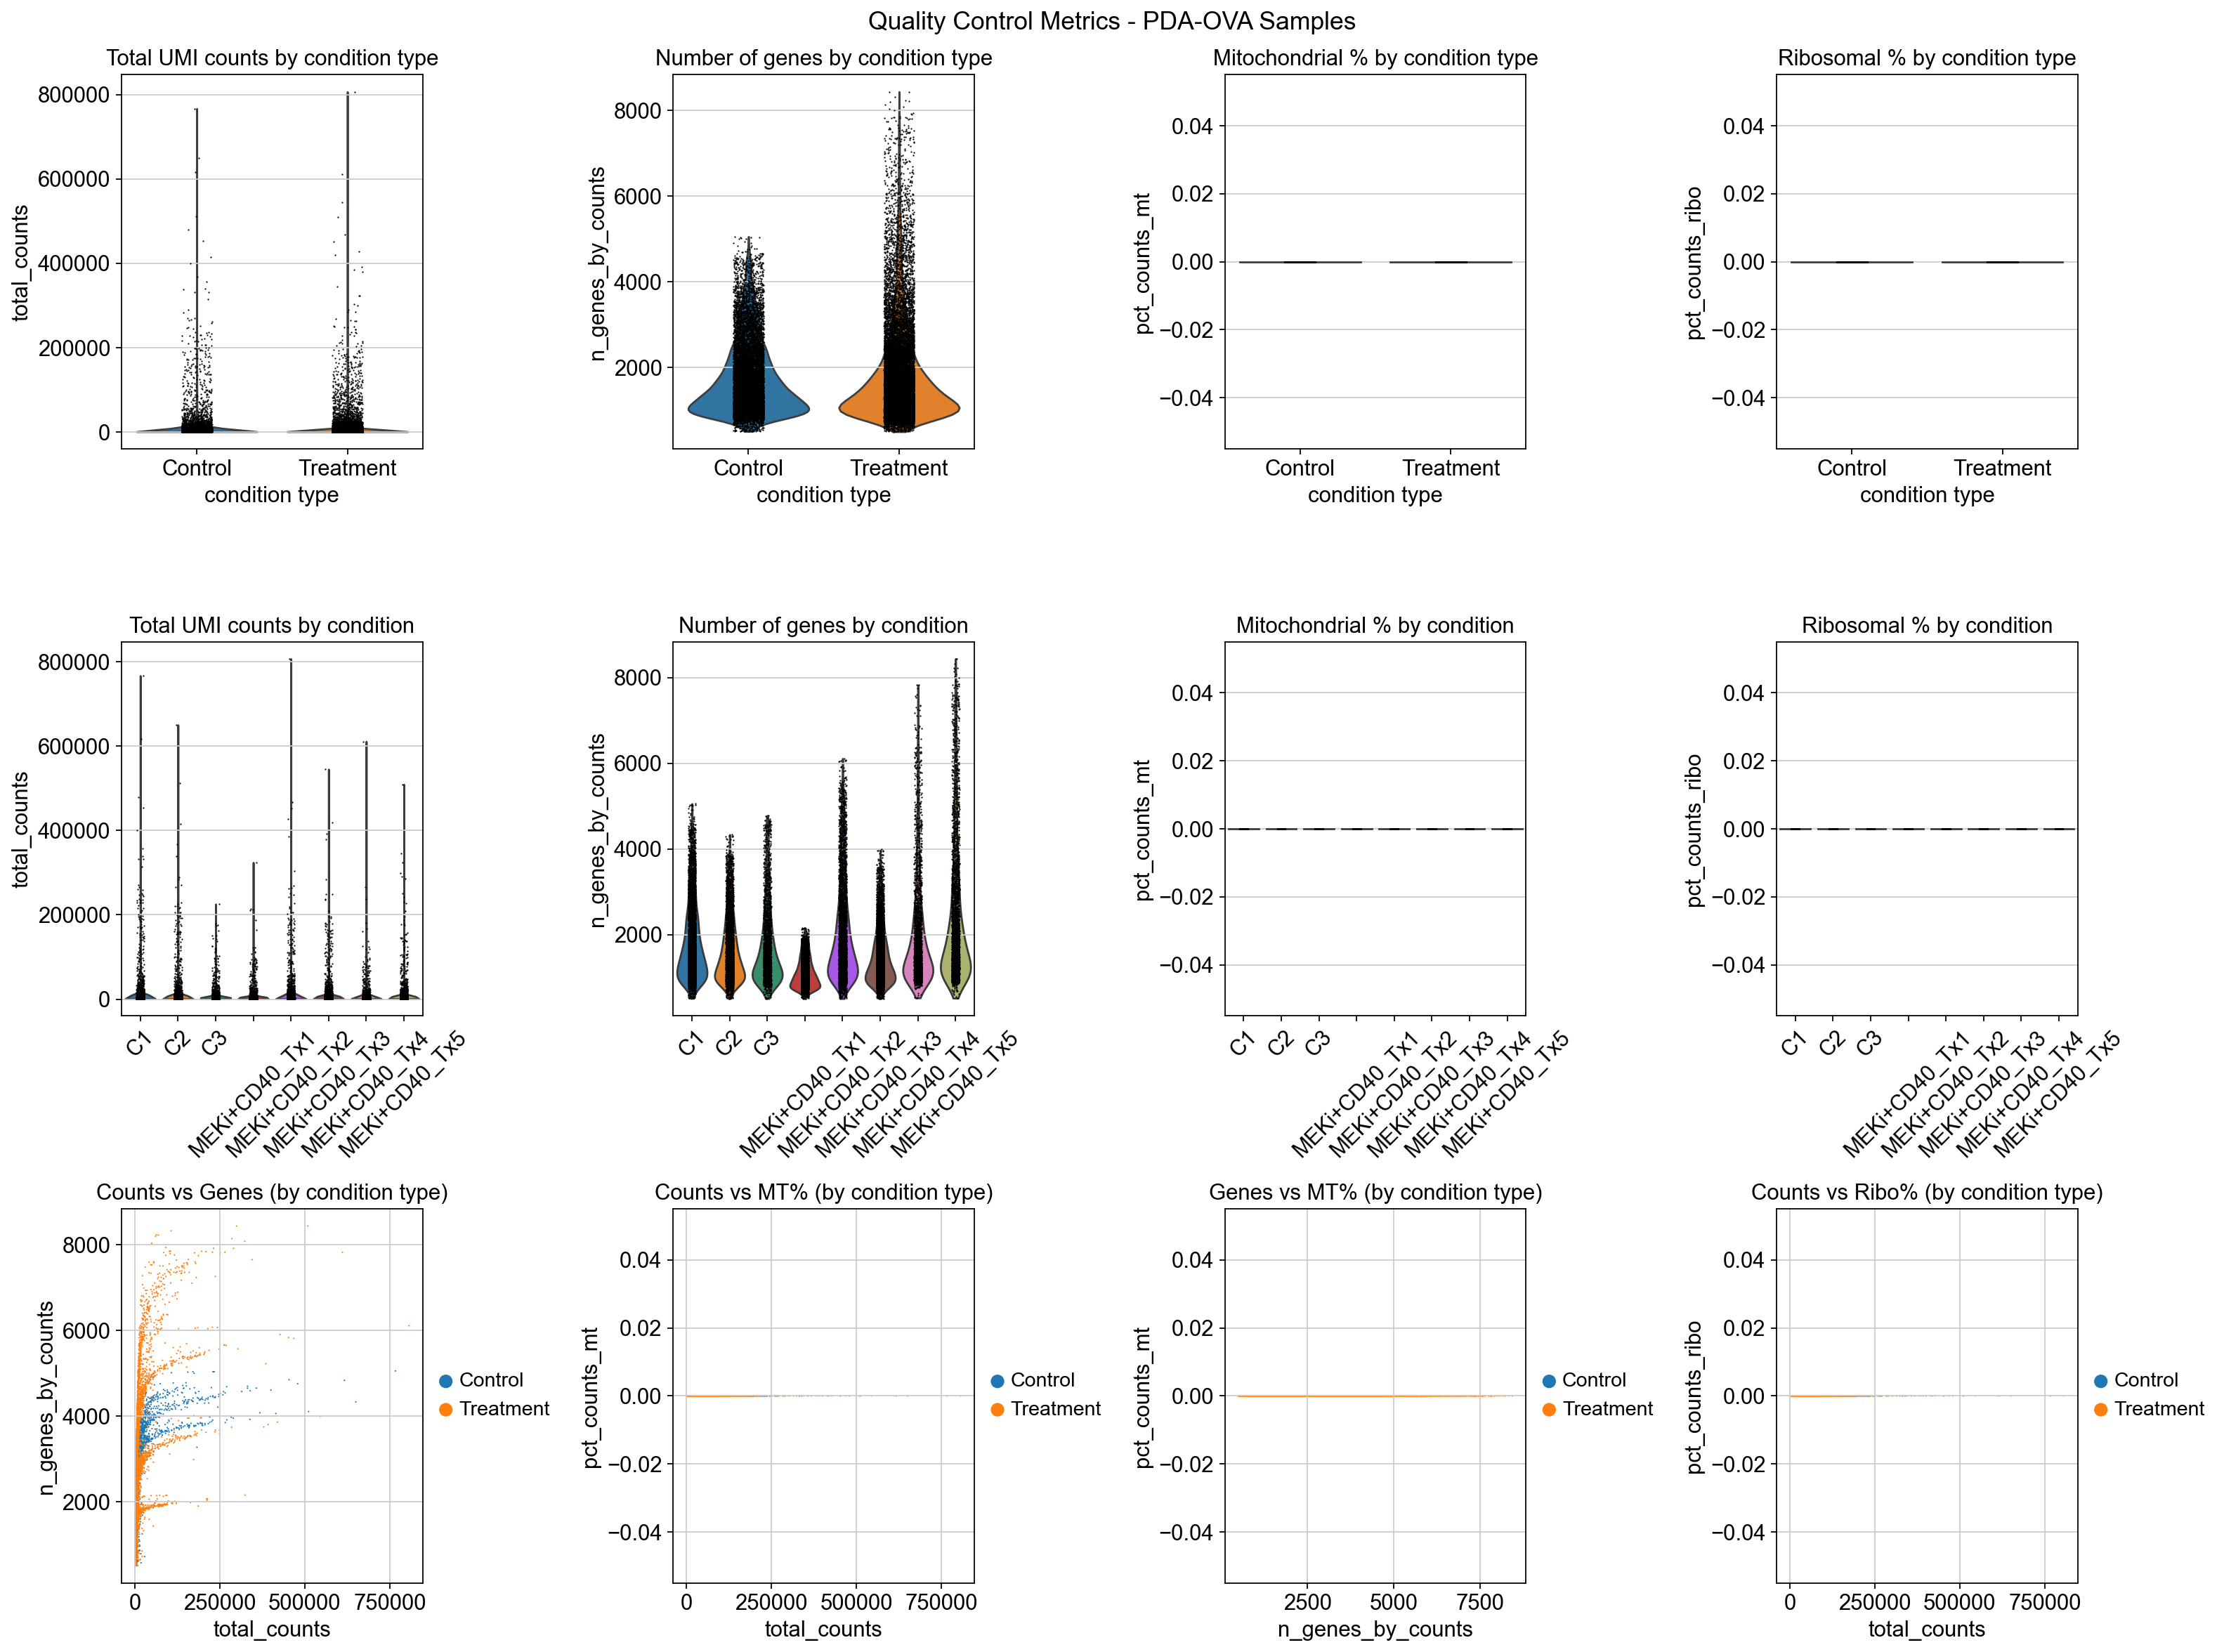

In [14]:
# Create comprehensive QC plots
fig, axes = plt.subplots(3, 4, figsize=(20, 15))
fig.suptitle('Quality Control Metrics - PDA-OVA Samples', fontsize=16)

# Row 1: Violin plots by condition type
sc.pl.violin(adata_combined, ['total_counts'], groupby='condition_type', ax=axes[0,0], show=False)
axes[0,0].set_title('Total UMI counts by condition type')

sc.pl.violin(adata_combined, ['n_genes_by_counts'], groupby='condition_type', ax=axes[0,1], show=False)
axes[0,1].set_title('Number of genes by condition type')

sc.pl.violin(adata_combined, ['pct_counts_mt'], groupby='condition_type', ax=axes[0,2], show=False)
axes[0,2].set_title('Mitochondrial % by condition type')

sc.pl.violin(adata_combined, ['pct_counts_ribo'], groupby='condition_type', ax=axes[0,3], show=False)
axes[0,3].set_title('Ribosomal % by condition type')

# Row 2: Violin plots by condition
sc.pl.violin(adata_combined, ['total_counts'], groupby='condition', ax=axes[1,0], show=False, rotation=45)
axes[1,0].set_title('Total UMI counts by condition')

sc.pl.violin(adata_combined, ['n_genes_by_counts'], groupby='condition', ax=axes[1,1], show=False, rotation=45)
axes[1,1].set_title('Number of genes by condition')

sc.pl.violin(adata_combined, ['pct_counts_mt'], groupby='condition', ax=axes[1,2], show=False, rotation=45)
axes[1,2].set_title('Mitochondrial % by condition')

sc.pl.violin(adata_combined, ['pct_counts_ribo'], groupby='condition', ax=axes[1,3], show=False, rotation=45)
axes[1,3].set_title('Ribosomal % by condition')

# Row 3: Scatter plots
sc.pl.scatter(adata_combined, x='total_counts', y='n_genes_by_counts', color='condition_type', ax=axes[2,0], show=False)
axes[2,0].set_title('Counts vs Genes (by condition type)')

sc.pl.scatter(adata_combined, x='total_counts', y='pct_counts_mt', color='condition_type', ax=axes[2,1], show=False)
axes[2,1].set_title('Counts vs MT% (by condition type)')

sc.pl.scatter(adata_combined, x='n_genes_by_counts', y='pct_counts_mt', color='condition_type', ax=axes[2,2], show=False)
axes[2,2].set_title('Genes vs MT% (by condition type)')

sc.pl.scatter(adata_combined, x='total_counts', y='pct_counts_ribo', color='condition_type', ax=axes[2,3], show=False)
axes[2,3].set_title('Counts vs Ribo% (by condition type)')

plt.tight_layout()
plt.show()


In [15]:
# Combine all processed PDA-OVA samples with TCR integration
if len(processed_samples_with_tcr) == 0:
    raise ValueError("No PDA-OVA samples were successfully processed with TCR integration!")

print("\\n" + "="*60)
print("COMBINING ALL PDA-OVA SAMPLES WITH TCR INTEGRATION")
print("="*60)

# Combine datasets
adata_combined_with_tcr = ad.concat(processed_samples_with_tcr, join='outer', index_unique='_')

print(f"Combined data shape: {adata_combined_with_tcr.shape}")
print(f"Total cells: {adata_combined_with_tcr.n_obs}")
print(f"Total genes: {adata_combined_with_tcr.n_vars}")

# Display sample composition
print("\\nSample composition:")
sample_counts = adata_combined_with_tcr.obs['sample_id'].value_counts()
for sample, count in sample_counts.items():
    print(f"  {sample}: {count:,} cells")

print("\\nCondition type distribution:")
condition_type_counts = adata_combined_with_tcr.obs['condition_type'].value_counts()
for condition_type, count in condition_type_counts.items():
    print(f"  {condition_type}: {count:,} cells")

print("\\nCondition distribution:")
condition_counts = adata_combined_with_tcr.obs['condition'].value_counts()
for condition, count in condition_counts.items():
    print(f"  {condition}: {count:,} cells")

print("\\nReplicate distribution:")
replicate_counts = adata_combined_with_tcr.obs['replicate'].value_counts()
for replicate, count in replicate_counts.items():
    print(f"  {replicate}: {count:,} cells")

# Display TCR statistics
print("\\nTCR Statistics:")
if 'has_paired_tcr' in adata_combined_with_tcr.obs.columns:
    n_cells_with_tcr = adata_combined_with_tcr.obs['has_paired_tcr'].notna().sum()
    # Convert to boolean for counting True values
    tcr_bool = adata_combined_with_tcr.obs['has_paired_tcr'].astype(str).map({'True': True, 'False': False, 'None': False, 'nan': False})
    n_cells_with_paired_tcr = tcr_bool.sum() if tcr_bool.notna().any() else 0
    alpha_bool = adata_combined_with_tcr.obs['has_alpha'].astype(str).map({'True': True, 'False': False, 'None': False, 'nan': False})
    n_cells_with_alpha = alpha_bool.sum() if alpha_bool.notna().any() else 0
    beta_bool = adata_combined_with_tcr.obs['has_beta'].astype(str).map({'True': True, 'False': False, 'None': False, 'nan': False})
    n_cells_with_beta = beta_bool.sum() if beta_bool.notna().any() else 0
    
    print(f"  Cells with TCR data: {n_cells_with_tcr:,} ({n_cells_with_tcr/adata_combined_with_tcr.n_obs*100:.1f}%)")
    print(f"  Cells with alpha chain: {n_cells_with_alpha:,} ({n_cells_with_alpha/adata_combined_with_tcr.n_obs*100:.1f}%)")
    print(f"  Cells with beta chain: {n_cells_with_beta:,} ({n_cells_with_beta/adata_combined_with_tcr.n_obs*100:.1f}%)")
    print(f"  Cells with paired TCR: {n_cells_with_paired_tcr:,} ({n_cells_with_paired_tcr/adata_combined_with_tcr.n_obs*100:.1f}%)")
    
    # TCR statistics by condition type
    print("\\nTCR Statistics by Condition Type:")
    for condition_type in adata_combined_with_tcr.obs['condition_type'].unique():
        if pd.notna(condition_type):
            subset = adata_combined_with_tcr.obs[adata_combined_with_tcr.obs['condition_type'] == condition_type]
            n_subset = len(subset)
            n_tcr_subset = subset['has_paired_tcr'].notna().sum()
            # Convert to boolean for counting True values
            subset_tcr_bool = subset['has_paired_tcr'].astype(str).map({'True': True, 'False': False, 'None': False, 'nan': False})
            n_paired_subset = subset_tcr_bool.sum() if subset_tcr_bool.notna().any() else 0
            
            print(f"  {condition_type}:")
            print(f"    Total cells: {n_subset:,}")
            print(f"    Cells with TCR: {n_tcr_subset:,} ({n_tcr_subset/n_subset*100:.1f}%)")
            print(f"    Cells with paired TCR: {n_paired_subset:,} ({n_paired_subset/n_subset*100:.1f}%)")
else:
    print("  No TCR data available in combined dataset")


\n============================================================
COMBINING ALL PDA-OVA SAMPLES WITH TCR INTEGRATION
Combined data shape: (32457, 41609)
Total cells: 32457
Total genes: 41609
\nSample composition:
  GSM6705374_PDA-OVA_C1: 5,500 cells
  GSM6705378_PDA-OVA_MEKi+CD40_Tx2: 5,235 cells
  GSM6705375_PDA-OVA_C2: 4,786 cells
  GSM6705379_PDA-OVA_MEKi+CD40_Tx3: 4,775 cells
  GSM6705381_PDA-OVA_MEKi+CD40_Tx5: 3,929 cells
  GSM6705377_PDA-OVA_MEKi+CD40_Tx1: 2,996 cells
  GSM6705380_PDA-OVA_MEKi+CD40_Tx4: 2,742 cells
  GSM6705376_PDA-OVA_C3: 2,494 cells
\nCondition type distribution:
  Treatment: 19,677 cells
  Control: 12,780 cells
\nCondition distribution:
  C1: 5,500 cells
  MEKi+CD40_Tx2: 5,235 cells
  C2: 4,786 cells
  MEKi+CD40_Tx3: 4,775 cells
  MEKi+CD40_Tx5: 3,929 cells
  MEKi+CD40_Tx1: 2,996 cells
  MEKi+CD40_Tx4: 2,742 cells
  C3: 2,494 cells
\nReplicate distribution:
  C1: 5,500 cells
  MEKi+CD40_Tx2: 5,235 cells
  C2: 4,786 cells
  MEKi+CD40_Tx3: 4,775 cells
  MEKi+CD40_T

In [16]:
# Save the combined PDA-OVA dataset
print("\\n" + "="*60)
print("SAVING COMBINED PDA-OVA DATASET")
print("="*60)

output_filename = 'PDA-OVA_combined_filtered.h5ad'
adata_combined.write(output_filename)

print(f"Data saved as '{output_filename}'")
print(f"\\nFinal dataset summary:")
print(f"  Shape: {adata_combined.shape}")
print(f"  Samples: {len(adata_combined.obs['sample_id'].unique())}")
print(f"  Condition types: {sorted(adata_combined.obs['condition_type'].unique())}")
print(f"  Conditions: {sorted(adata_combined.obs['condition'].unique())}")
print(f"  Total cells after filtering: {adata_combined.n_obs:,}")
print(f"  Total genes: {adata_combined.n_vars:,}")


\n============================================================
SAVING COMBINED PDA-OVA DATASET
Data saved as 'PDA-OVA_combined_filtered.h5ad'
\nFinal dataset summary:
  Shape: (32457, 41609)
  Samples: 8
  Condition types: ['Control', 'Treatment']
  Conditions: ['C1', 'C2', 'C3', 'MEKi+CD40_Tx1', 'MEKi+CD40_Tx2', 'MEKi+CD40_Tx3', 'MEKi+CD40_Tx4', 'MEKi+CD40_Tx5']
  Total cells after filtering: 32,457
  Total genes: 41,609


In [17]:
# Calculate comprehensive QC metrics with TCR integration
print("\\n" + "="*60)
print("CALCULATING QC METRICS WITH TCR INTEGRATION")
print("="*60)

# Use the TCR-integrated dataset
adata_combined = adata_combined_with_tcr

# Make variable names unique
adata_combined.var_names_make_unique()

# Identify mitochondrial and ribosomal genes (mouse)
adata_combined.var['mt'] = adata_combined.var_names.str.startswith('mt-')  # mouse mitochondrial genes
adata_combined.var['ribo'] = adata_combined.var_names.str.startswith(('Rps', 'Rpl'))  # mouse ribosomal genes

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata_combined, percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)
sc.pp.calculate_qc_metrics(adata_combined, qc_vars=['ribo'], percent_top=None, log1p=False, inplace=True)

print("QC metrics calculated successfully!")

# Display basic statistics
print("\\nQuality Control Statistics:")
print(f"\\nTotal UMI counts per cell:")
print(adata_combined.obs['total_counts'].describe())

print(f"\\nNumber of genes per cell:")
print(adata_combined.obs['n_genes_by_counts'].describe())

print(f"\\nMitochondrial gene percentage:")
print(adata_combined.obs['pct_counts_mt'].describe())

print(f"\\nRibosomal gene percentage:")
print(adata_combined.obs['pct_counts_ribo'].describe())

# Display TCR-related statistics
if 'has_paired_tcr' in adata_combined.obs.columns:
    print("\\nTCR Quality Control Statistics:")
    
    # Compare QC metrics between cells with and without TCR
    tcr_cells = adata_combined.obs['has_paired_tcr'].notna()
    no_tcr_cells = adata_combined.obs['has_paired_tcr'].isna()
    
    print(f"\\nTotal UMI counts - Cells with TCR vs without TCR:")
    print(f"  With TCR: {adata_combined.obs.loc[tcr_cells, 'total_counts'].describe()}")
    print(f"  Without TCR: {adata_combined.obs.loc[no_tcr_cells, 'total_counts'].describe()}")
    
    print(f"\\nNumber of genes - Cells with TCR vs without TCR:")
    print(f"  With TCR: {adata_combined.obs.loc[tcr_cells, 'n_genes_by_counts'].describe()}")
    print(f"  Without TCR: {adata_combined.obs.loc[no_tcr_cells, 'n_genes_by_counts'].describe()}")
    
    print(f"\\nMitochondrial % - Cells with TCR vs without TCR:")
    print(f"  With TCR: {adata_combined.obs.loc[tcr_cells, 'pct_counts_mt'].describe()}")
    print(f"  Without TCR: {adata_combined.obs.loc[no_tcr_cells, 'pct_counts_mt'].describe()}")


\n============================================================
CALCULATING QC METRICS WITH TCR INTEGRATION
QC metrics calculated successfully!
\nQuality Control Statistics:
\nTotal UMI counts per cell:
count     32457.000000
mean       7001.586914
std       23720.460938
min        1000.000000
25%        1455.000000
50%        2246.000000
75%        4377.000000
max      806603.000000
Name: total_counts, dtype: float64
\nNumber of genes per cell:
count    32457.000000
mean      1783.034107
std       1044.237774
min        501.000000
25%       1058.000000
50%       1446.000000
75%       2174.000000
max       8439.000000
Name: n_genes_by_counts, dtype: float64
\nMitochondrial gene percentage:
count    32457.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0
75%          0.0
max          0.0
Name: pct_counts_mt, dtype: float64
\nRibosomal gene percentage:
count    32457.0
mean         0.0
std          0.0
min          0.0
25%          0.0
50%          0.0

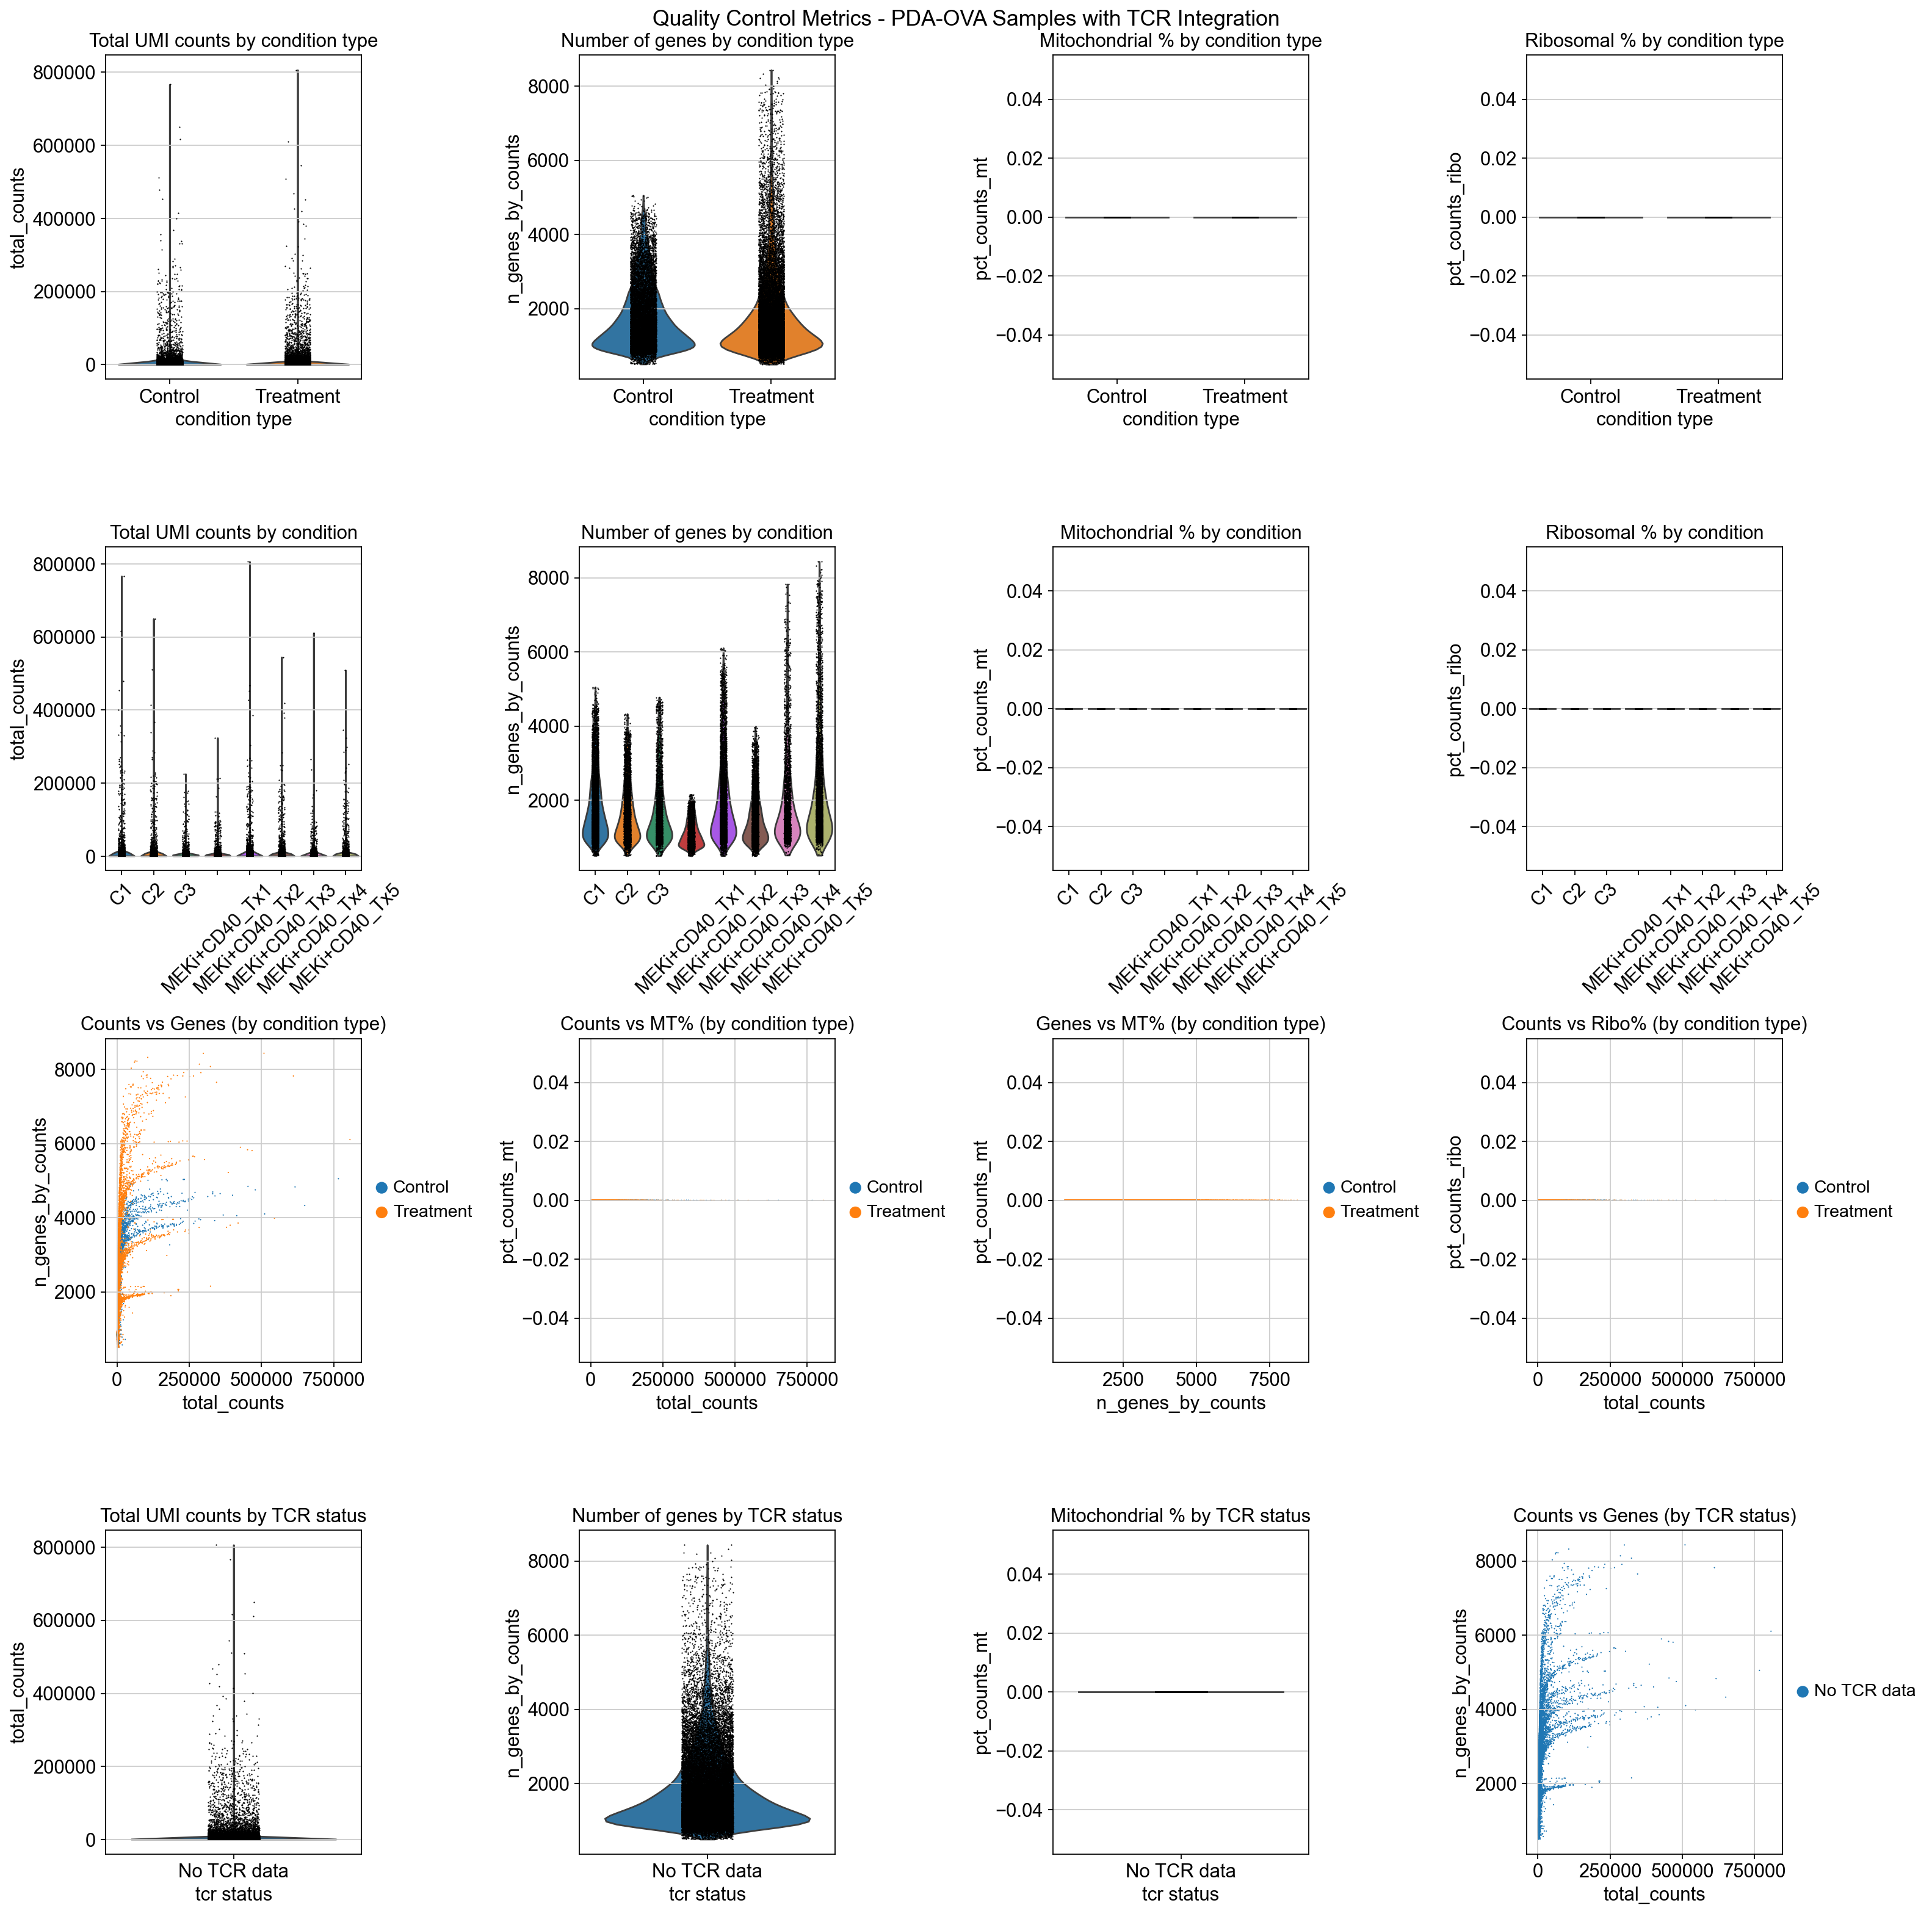

In [18]:
# Create comprehensive QC plots with TCR information
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Quality Control Metrics - PDA-OVA Samples with TCR Integration', fontsize=16)

# Row 1: Violin plots by condition type
sc.pl.violin(adata_combined, ['total_counts'], groupby='condition_type', ax=axes[0,0], show=False)
axes[0,0].set_title('Total UMI counts by condition type')

sc.pl.violin(adata_combined, ['n_genes_by_counts'], groupby='condition_type', ax=axes[0,1], show=False)
axes[0,1].set_title('Number of genes by condition type')

sc.pl.violin(adata_combined, ['pct_counts_mt'], groupby='condition_type', ax=axes[0,2], show=False)
axes[0,2].set_title('Mitochondrial % by condition type')

sc.pl.violin(adata_combined, ['pct_counts_ribo'], groupby='condition_type', ax=axes[0,3], show=False)
axes[0,3].set_title('Ribosomal % by condition type')

# Row 2: Violin plots by condition
sc.pl.violin(adata_combined, ['total_counts'], groupby='condition', ax=axes[1,0], show=False, rotation=45)
axes[1,0].set_title('Total UMI counts by condition')

sc.pl.violin(adata_combined, ['n_genes_by_counts'], groupby='condition', ax=axes[1,1], show=False, rotation=45)
axes[1,1].set_title('Number of genes by condition')

sc.pl.violin(adata_combined, ['pct_counts_mt'], groupby='condition', ax=axes[1,2], show=False, rotation=45)
axes[1,2].set_title('Mitochondrial % by condition')

sc.pl.violin(adata_combined, ['pct_counts_ribo'], groupby='condition', ax=axes[1,3], show=False, rotation=45)
axes[1,3].set_title('Ribosomal % by condition')

# Row 3: Scatter plots
sc.pl.scatter(adata_combined, x='total_counts', y='n_genes_by_counts', color='condition_type', ax=axes[2,0], show=False)
axes[2,0].set_title('Counts vs Genes (by condition type)')

sc.pl.scatter(adata_combined, x='total_counts', y='pct_counts_mt', color='condition_type', ax=axes[2,1], show=False)
axes[2,1].set_title('Counts vs MT% (by condition type)')

sc.pl.scatter(adata_combined, x='n_genes_by_counts', y='pct_counts_mt', color='condition_type', ax=axes[2,2], show=False)
axes[2,2].set_title('Genes vs MT% (by condition type)')

sc.pl.scatter(adata_combined, x='total_counts', y='pct_counts_ribo', color='condition_type', ax=axes[2,3], show=False)
axes[2,3].set_title('Counts vs Ribo% (by condition type)')

# Row 4: TCR-related plots (if TCR data is available)
if 'has_paired_tcr' in adata_combined.obs.columns:
    # Create a binary TCR status column for plotting
    adata_combined.obs['tcr_status'] = adata_combined.obs['has_paired_tcr'].apply(
        lambda x: 'With TCR' if pd.notna(x) and x else 'Without TCR' if pd.notna(x) else 'No TCR data'
    )
    
    sc.pl.violin(adata_combined, ['total_counts'], groupby='tcr_status', ax=axes[3,0], show=False)
    axes[3,0].set_title('Total UMI counts by TCR status')
    
    sc.pl.violin(adata_combined, ['n_genes_by_counts'], groupby='tcr_status', ax=axes[3,1], show=False)
    axes[3,1].set_title('Number of genes by TCR status')
    
    sc.pl.violin(adata_combined, ['pct_counts_mt'], groupby='tcr_status', ax=axes[3,2], show=False)
    axes[3,2].set_title('Mitochondrial % by TCR status')
    
    sc.pl.scatter(adata_combined, x='total_counts', y='n_genes_by_counts', color='tcr_status', ax=axes[3,3], show=False)
    axes[3,3].set_title('Counts vs Genes (by TCR status)')
else:
    # Hide the last row if no TCR data
    for i in range(4):
        axes[3,i].set_visible(False)

plt.tight_layout()
plt.show()


In [19]:
# Save the combined PDA-OVA dataset with TCR integration
print("\\n" + "="*60)
print("SAVING COMBINED PDA-OVA DATASET WITH TCR INTEGRATION")
print("="*60)

# Convert to memory to avoid Dataset2D issues
print("Converting dataset to memory...")
adata_combined = adata_combined.to_memory()

# Additional conversion to ensure all data is in memory
print("Ensuring all data structures are in memory...")
if hasattr(adata_combined.X, 'toarray'):
    adata_combined.X = adata_combined.X.toarray()
if hasattr(adata_combined.raw, 'X') and adata_combined.raw is not None:
    if hasattr(adata_combined.raw.X, 'toarray'):
        adata_combined.raw.X = adata_combined.raw.X.toarray()

# Clean up observation metadata to avoid data type issues
print("Cleaning observation metadata...")
for col in adata_combined.obs.columns:
    if adata_combined.obs[col].dtype == 'object':
        # Convert object columns to string to avoid issues
        adata_combined.obs[col] = adata_combined.obs[col].astype(str)
    elif adata_combined.obs[col].dtype.name == 'category':
        # Convert categorical columns to string to avoid issues
        adata_combined.obs[col] = adata_combined.obs[col].astype(str)

output_filename = 'PDA-OVA_combined_with_TCR_filtered.h5ad'
print(f"Saving to {output_filename}...")

# Try saving with different options
try:
    adata_combined.write(output_filename)
    print("✓ Successfully saved with default options")
except Exception as e:
    print(f"Default save failed: {e}")
    print("Trying alternative save method...")
    try:
        # Try saving with as_dense=True to force dense format
        adata_combined.write(output_filename, as_dense=True)
        print("✓ Successfully saved with as_dense=True")
    except Exception as e2:
        print(f"Alternative save also failed: {e2}")
        print("Trying to save as CSV files instead...")
        # Save as separate files
        adata_combined.obs.to_csv('PDA-OVA_obs_metadata.csv')
        adata_combined.var.to_csv('PDA-OVA_var_metadata.csv')
        print("✓ Saved metadata as CSV files")
        raise e2

print(f"Data saved as '{output_filename}'")
print(f"\\nFinal dataset summary:")
print(f"  Shape: {adata_combined.shape}")
print(f"  Samples: {len(adata_combined.obs['sample_id'].unique())}")
print(f"  Condition types: {sorted(adata_combined.obs['condition_type'].unique())}")
print(f"  Conditions: {sorted(adata_combined.obs['condition'].unique())}")
print(f"  Total cells after filtering: {adata_combined.n_obs:,}")
print(f"  Total genes: {adata_combined.n_vars:,}")

# TCR summary
if 'has_paired_tcr' in adata_combined.obs.columns:
    n_cells_with_tcr = adata_combined.obs['has_paired_tcr'].notna().sum()
    # Convert to boolean for counting True values
    tcr_bool = adata_combined.obs['has_paired_tcr'].astype(str).map({'True': True, 'False': False, 'None': False, 'nan': False})
    n_cells_with_paired_tcr = tcr_bool.sum() if tcr_bool.notna().any() else 0
    print(f"  Cells with TCR data: {n_cells_with_tcr:,} ({n_cells_with_tcr/adata_combined.n_obs*100:.1f}%)")
    print(f"  Cells with paired TCR: {n_cells_with_paired_tcr:,} ({n_cells_with_paired_tcr/adata_combined.n_obs*100:.1f}%)")
    
    # List TCR-related columns
    tcr_columns = [col for col in adata_combined.obs.columns if col.startswith(('has_', 'alpha_', 'beta_', 'clonotype_', 'n_', 'tcr_'))]
    print(f"  TCR-related columns: {len(tcr_columns)}")
    print(f"    {tcr_columns}")
else:
    print(f"  No TCR data integrated")


\n============================================================
SAVING COMBINED PDA-OVA DATASET WITH TCR INTEGRATION
Converting dataset to memory...
Ensuring all data structures are in memory...
Cleaning observation metadata...
Saving to PDA-OVA_combined_with_TCR_filtered.h5ad...
✓ Successfully saved with default options
Data saved as 'PDA-OVA_combined_with_TCR_filtered.h5ad'
\nFinal dataset summary:
  Shape: (32457, 41609)
  Samples: 8
  Condition types: ['Control', 'Treatment']
  Conditions: ['C1', 'C2', 'C3', 'MEKi+CD40_Tx1', 'MEKi+CD40_Tx2', 'MEKi+CD40_Tx3', 'MEKi+CD40_Tx4', 'MEKi+CD40_Tx5']
  Total cells after filtering: 32,457
  Total genes: 41,609
  Cells with TCR data: 32,457 (100.0%)
  Cells with paired TCR: 0 (0.0%)
  TCR-related columns: 27
    ['n_counts', 'n_genes', 'has_alpha', 'has_beta', 'has_paired_tcr', 'n_alpha_chains', 'n_beta_chains', 'alpha_v_gene', 'alpha_j_gene', 'alpha_c_gene', 'alpha_cdr3', 'alpha_cdr3_nt', 'alpha_raw_clonotype_id', 'beta_v_gene', 'beta_d_gene'

In [20]:
# import scanpy as sc
# adata_combined = sc.read('PDA-OVA_combined_with_TCR_filtered.h5ad')

In [21]:
adata_combined

AnnData object with n_obs × n_vars = 32457 × 41609
    obs: 'gene_ids', 'feature_types', 'gsm_id', 'condition', 'condition_type', 'replicate', 'sample_id', 'n_counts', 'n_genes', 'has_alpha', 'has_beta', 'has_paired_tcr', 'n_alpha_chains', 'n_beta_chains', 'total_tcr_chains', 'alpha_v_gene', 'alpha_j_gene', 'alpha_c_gene', 'alpha_cdr3', 'alpha_cdr3_nt', 'alpha_raw_clonotype_id', 'beta_v_gene', 'beta_d_gene', 'beta_j_gene', 'beta_c_gene', 'beta_cdr3', 'beta_cdr3_nt', 'beta_raw_clonotype_id', 'clonotype_id', 'clonotype_frequency', 'clonotype_proportion', 'clonotype_cdr3s_aa', 'clonotype_cdr3s_nt', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'tcr_status'
    var: 'mt', 'ribo', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'condition_type_colors', 'condition_colors', 'tcr_status_colors'

In [22]:
adata_combined.obs['beta_cdr3']

Mrpl15_0            None
Lypla1_0            None
Tcea1_0             None
Atp6v1h_0           None
Rb1cc1_0            None
                    ... 
mt-Nd6_7            None
mt-Cytb_7           None
AC149090.1_7        None
CAAA01118383.1_7    None
CAAA01147332.1_7    None
Name: beta_cdr3, Length: 32457, dtype: category
Categories (1, object): ['None']

In [23]:
# Check how many beta_cdr3 values are not None
beta_cdr3_not_none = adata_combined.obs['beta_cdr3'] != 'None'
print(f"Cells with beta CDR3 (not None): {beta_cdr3_not_none.sum():,}")
print(f"Total cells: {len(adata_combined.obs):,}")
print(f"Percentage with beta CDR3: {beta_cdr3_not_none.sum()/len(adata_combined.obs)*100:.1f}%")

Cells with beta CDR3 (not None): 0
Total cells: 32,457
Percentage with beta CDR3: 0.0%


## Summary

This notebook has successfully:

1. **Processed all PDA-OVA 10X Genomics files** in the directory using an automated loop
2. **Applied quality control filtering**:
   - `min_counts=1000`: Removed cells with fewer than 1000 UMI counts (empty droplets)
   - `min_genes=500`: Removed cells expressing fewer than 500 genes
3. **Combined all PDA-OVA samples** into a single AnnData object with proper metadata
4. **Extracted metadata** from filenames including:
   - GSM ID
   - Condition (C1, C2, C3, MEKi+CD40_Tx1-5)
   - Condition type (Control vs Treatment)
   - Replicate information
5. **Integrated TCR data** from clonotypes and filtered contig annotations:
   - Loaded clonotypes.csv.gz files with clonotype information
   - Loaded filtered_contig_annotations.csv.gz files with TCR chain details
   - Paired TCR data with GEX data using cell barcodes
   - Added comprehensive TCR metadata to each cell
6. **Calculated comprehensive QC metrics**:
   - Total UMI counts per cell
   - Number of genes per cell
   - Mitochondrial gene percentage
   - Ribosomal gene percentage
   - TCR-specific quality metrics
7. **Generated quality control visualizations** comparing metrics across conditions, condition types, and TCR status
8. **Saved the processed dataset** with integrated TCR data for downstream analysis

## Dataset Overview

- **Total PDA-OVA samples**: 8 samples
- **Control samples**: C1, C2, C3 (3 samples)
- **Treatment samples**: MEKi+CD40_Tx1, MEKi+CD40_Tx2, MEKi+CD40_Tx3, MEKi+CD40_Tx4, MEKi+CD40_Tx5 (5 samples)
- **Data format**: 10X Genomics (barcodes.tsv.gz, features.tsv.gz, matrix.mtx.gz)
- **TCR data format**: Cell Ranger V(D)J output (clonotypes.csv.gz, filtered_contig_annotations.csv.gz)

## TCR Integration Features

The integrated dataset includes the following TCR-related information for each cell:

- **TCR Chain Information**: Alpha and beta chain presence, gene usage, CDR3 sequences
- **Clonotype Data**: Clonotype ID, frequency, proportion, combined CDR3 sequences
- **Quality Metrics**: Number of chains per cell, productive vs non-productive chains
- **Cell Classification**: Cells with paired TCR, alpha-only, beta-only, or no TCR

## Next Steps

The combined, filtered PDA-OVA dataset with integrated TCR data is now ready for:

1. **Further Quality Control**: Additional filtering based on the QC plots and TCR quality
2. **Normalization**: Log normalization and scaling
3. **Feature Selection**: Identify highly variable genes
4. **Dimensionality Reduction**: PCA, UMAP, t-SNE
5. **Batch Correction**: If needed, correct for batch effects between samples
6. **Clustering**: Identify cell populations (both GEX and TCR-based)
7. **Differential Expression**: Compare gene expression between control and treatment conditions
8. **Cell Type Annotation**: Identify specific cell populations using both GEX and TCR markers
9. **Treatment Response Analysis**: Study the effects of MEKi+CD40 treatment on both gene expression and TCR repertoire
10. **TCR Repertoire Analysis**: 
    - Clonotype diversity analysis
    - TCR sharing between conditions
    - CDR3 sequence analysis
    - V(D)J gene usage patterns
11. **Immune Cell Analysis**: Focus on T cell populations and their response to treatment
12. **TCR-GEX Integration**: Correlate TCR characteristics with gene expression patterns
